In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['font.size'] = 12
df = pd.read_csv('airport-codes.csv') 


In [5]:
print("="*60)
print("تمرین دوم: پیش‌پردازش داده")
print("="*60)

تمرین دوم: پیش‌پردازش داده


In [7]:
print(f"دیتاست اصلی: {df.shape}")
print(df.head())

دیتاست اصلی: (57909, 18)
       id ident           type                                name  \
0    6523   00A       heliport                   Total Rf Heliport   
1  323361  00AA  small_airport                Aero B Ranch Airport   
2    6524  00AK  small_airport                        Lowell Field   
3    6525  00AL  small_airport                        Epps Airpark   
4    6526  00AR         closed  Newport Hospital & Clinic Heliport   

   latitude_deg  longitude_deg  elevation_ft continent iso_country iso_region  \
0     40.070801     -74.933601          11.0       NaN          US      US-PA   
1     38.704022    -101.473911        3435.0       NaN          US      US-KS   
2     59.949200    -151.695999         450.0       NaN          US      US-AK   
3     34.864799     -86.770302         820.0       NaN          US      US-AL   
4     35.608700     -91.254898         237.0       NaN          US      US-AR   

   municipality scheduled_service gps_code iata_code local_code hom

In [8]:
# ایجاد یک کپی برای کار
df_processed = df.copy()

پاکسازی داده (Data Cleaning)

 داده‌های گمشده قبل از پاکسازی:
Series([], dtype: int64)

پر کردن داده‌های گمشده...

داده‌های گمشده بعد از پاکسازی:
هیچ داده گمشده‌ای وجود ندارد!


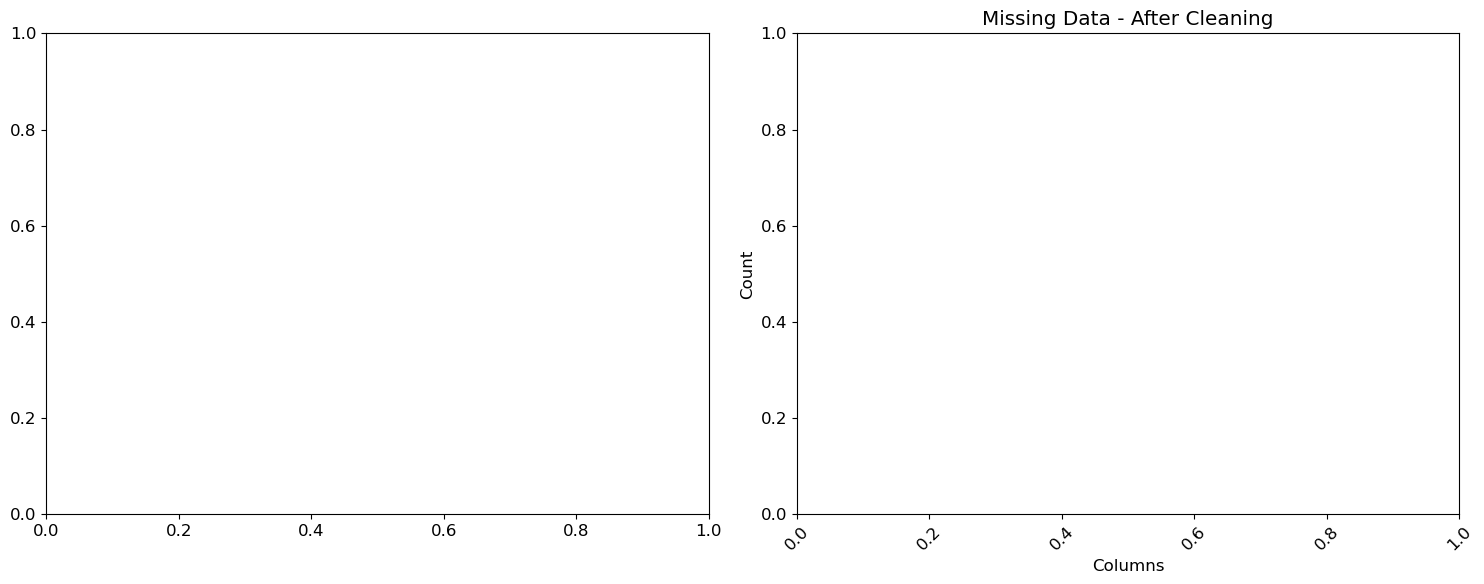


حذف داده‌های تکراری...
تعداد داده‌های تکراری قبل از حذف: 0
ابعاد دیتاست بعد از حذف تکراری‌ها: (57909, 18)

شناسایی داده‌های پرت با روش IQR...

  ستون 'id':
    - محدوده مجاز: [-32984.50, 93923.50]
    - تعداد داده پرت: 14167 (24.46%)

  ستون 'latitude_deg':
    - محدوده مجاز: [-46.87, 98.05]
    - تعداد داده پرت: 166 (0.29%)

  ستون 'longitude_deg':
    - محدوده مجاز: [-251.87, 174.00]
    - تعداد داده پرت: 154 (0.27%)

  ستون 'elevation_ft':
    - محدوده مجاز: [-1250.00, 2830.00]
    - تعداد داده پرت: 6185 (10.68%)


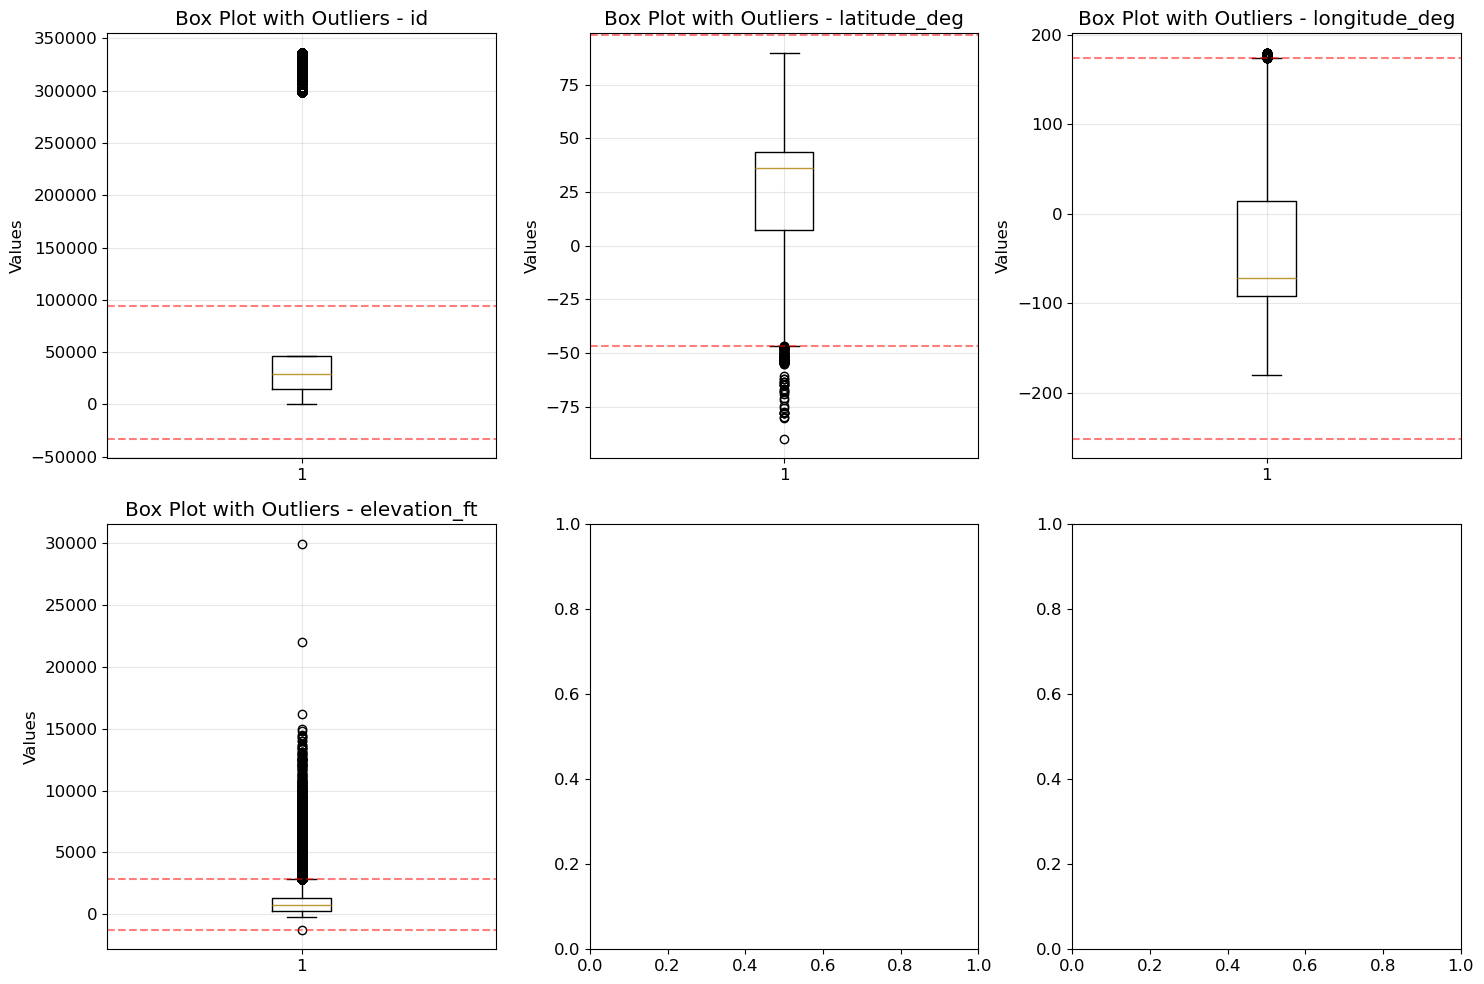

In [10]:
# بخش 1: Data Cleaning (پاکسازی داده)
print("="*60)
print("پاکسازی داده (Data Cleaning)")
print("="*60)

# بررسی داده‌های گمشده
print("\n داده‌های گمشده قبل از پاکسازی:")
missing_before = df_processed.isnull().sum()
print(missing_before[missing_before > 0])

# رسم نمودار داده‌های گمشده قبل از پاکسازی
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# قبل از پاکسازی
missing_before_plot = missing_before[missing_before > 0]
if len(missing_before_plot) > 0:
    axes[0].bar(missing_before_plot.index, missing_before_plot.values, color='red', alpha=0.7)
    axes[0].set_title('Missing Data - Before Cleaning')
    axes[0].set_xlabel('Columns')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

#پر کردن داده‌های گمشده
print("\nپر کردن داده‌های گمشده...")

# برای ستون‌های عددی: پر کردن با میانه
numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        median_val = df_processed[col].median()
        df_processed[col].fillna(median_val, inplace=True)
        print(f"  ستون '{col}': {missing_before[col]} مقدار گمشده با میانه ({median_val:.2f}) پر شد")

# برای ستون‌های غیرعددی: پر کردن با مد
categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        mode_val = df_processed[col].mode()[0]
        df_processed[col].fillna(mode_val, inplace=True)
        print(f"  ستون '{col}': {missing_before[col]} مقدار گمشده با مد ({mode_val}) پر شد")

# بررسی داده‌های گمشده بعد از پاکسازی
print("\nداده‌های گمشده بعد از پاکسازی:")
missing_after = df_processed.isnull().sum()
print(missing_after[missing_after > 0] if missing_after.sum() > 0 else "هیچ داده گمشده‌ای وجود ندارد!")

# بعد از پاکسازی
missing_after_plot = missing_after[missing_after > 0]
if len(missing_after_plot) > 0:
    axes[1].bar(missing_after_plot.index, missing_after_plot.values, color='green', alpha=0.7)
axes[1].set_title('Missing Data - After Cleaning')
axes[1].set_xlabel('Columns')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data_cleaning_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#حذف داده‌های تکراری
print("\nحذف داده‌های تکراری...")
duplicates_before = df_processed.duplicated().sum()
print(f"تعداد داده‌های تکراری قبل از حذف: {duplicates_before}")
df_processed.drop_duplicates(inplace=True)
print(f"ابعاد دیتاست بعد از حذف تکراری‌ها: {df_processed.shape}")

# شناسایی و مدیریت داده‌های پرت (Outliers) با روش IQR
print("\nشناسایی داده‌های پرت با روش IQR...")

outlier_info = {}
for col in numeric_cols[:5]:  # بررسی 5 ستون عددی اول
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_processed[(df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percent = (outlier_count / len(df_processed)) * 100
    
    outlier_info[col] = {
        'count': outlier_count,
        'percent': outlier_percent,
        'lower': lower_bound,
        'upper': upper_bound
    }
    
    print(f"\n  ستون '{col}':")
    print(f"    - محدوده مجاز: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"    - تعداد داده پرت: {outlier_count} ({outlier_percent:.2f}%)")

# رسم باکس پلات برای نمایش داده‌های پرت
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].boxplot(df_processed[col].dropna())
    axes[idx].set_title(f'Box Plot with Outliers - {col}')
    axes[idx].set_ylabel('Values')
    axes[idx].grid(True, alpha=0.3)
    
    # اضافه کردن خطوط مرزی
    if col in outlier_info:
        axes[idx].axhline(y=outlier_info[col]['lower'], color='r', linestyle='--', alpha=0.5, label='Lower Bound')
        axes[idx].axhline(y=outlier_info[col]['upper'], color='r', linestyle='--', alpha=0.5, label='Upper Bound')

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=300, bbox_inches='tight')
plt.show()


تبدیل داده (Data Transformation)

نرمال‌سازی داده‌های عددی (Min-Max)...
داده‌ها قبل از نرمال‌سازی:
                  id  latitude_deg  longitude_deg  elevation_ft
count   57909.000000  57909.000000   57909.000000  57909.000000
mean    96005.380321     25.494921     -34.894796   1179.830959
std    129429.639322     27.286100      79.835232   1508.671698
min         2.000000    -90.000000    -179.876999  -1266.000000
25%     14606.000000      7.477794     -92.168198    280.000000
50%     29236.000000     36.116699     -71.475304    724.000000
75%     46333.000000     43.708302      14.300332   1300.000000
max    336313.000000     90.000000     179.999894  29977.000000

داده‌ها بعد از نرمال‌سازی (بازه 0 تا 1):
                 id  latitude_deg  longitude_deg  elevation_ft
count  57909.000000  57909.000000   57909.000000  57909.000000
mean       0.285460      0.641638       0.402866      0.078284
std        0.384851      0.151589       0.221840      0.048288
min        0.000000      0.000

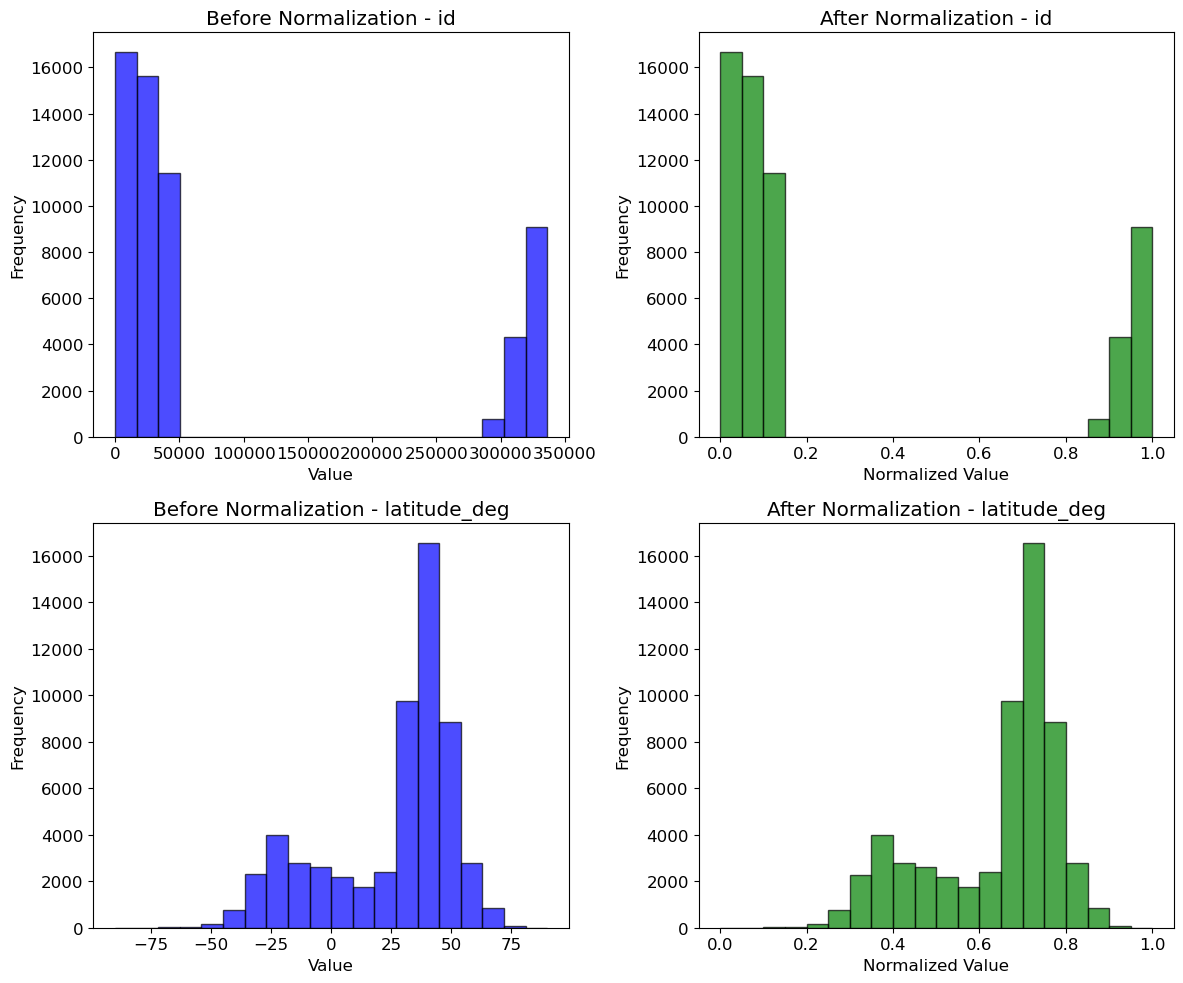


استانداردسازی داده‌ها (Z-Score)...
داده‌ها بعد از استانداردسازی (میانگین=0، انحراف معیار=1):
                 id  latitude_deg  longitude_deg  elevation_ft
count  5.790900e+04  5.790900e+04   5.790900e+04  5.790900e+04
mean   1.472399e-17 -5.595115e-17  -1.177919e-17 -5.104315e-17
std    1.000009e+00  1.000009e+00   1.000009e+00  1.000009e+00
min   -7.417483e-01 -4.232775e+00  -1.816033e+00 -1.621196e+00
25%   -6.289138e-01 -6.603100e-01  -7.174013e-01 -5.964444e-01
50%   -5.158784e-01  3.892777e-01  -4.582040e-01 -3.021432e-01
75%   -3.837823e-01  6.675024e-01   6.162136e-01  7.965290e-02
max    1.856682e+00  2.364047e+00   2.691751e+00  1.908793e+01

تبدیل داده‌های دسته‌بندی به عددی...
  ستون 'ident' به 'ident_encoded' تبدیل شد
    - مقادیر یکتا: 57909
  ستون 'type' به 'type_encoded' تبدیل شد
    - مقادیر یکتا: 7
  ستون 'name' به 'name_encoded' تبدیل شد
    - مقادیر یکتا: 54842

نمونه تبدیل برای 'ident':
  ident  ident_encoded
0   00A              0
1  00AA              1
2  00AK   

In [11]:

# Data Transformation (تبدیل داده)

print("\n" + "="*60)
print("تبدیل داده (Data Transformation)")
print("="*60)

#نرمال‌سازی (Normalization) با Min-Max Scaler
print("\nنرمال‌سازی داده‌های عددی (Min-Max)...")
scaler_minmax = MinMaxScaler()

# انتخاب ستون‌های عددی برای نرمال‌سازی
cols_to_normalize = numeric_cols[:4]  # 4 ستون عددی اول
df_normalized = df_processed.copy()

# اعمال نرمال‌سازی
df_normalized[cols_to_normalize] = scaler_minmax.fit_transform(df_processed[cols_to_normalize])

print("داده‌ها قبل از نرمال‌سازی:")
print(df_processed[cols_to_normalize].describe())
print("\nداده‌ها بعد از نرمال‌سازی (بازه 0 تا 1):")
print(df_normalized[cols_to_normalize].describe())

# رسم نمودار مقایسه قبل و بعد از نرمال‌سازی
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for idx, col in enumerate(cols_to_normalize[:2]):
    # قبل از نرمال‌سازی
    axes[idx, 0].hist(df_processed[col].dropna(), bins=20, color='blue', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'Before Normalization - {col}')
    axes[idx, 0].set_xlabel('Value')
    axes[idx, 0].set_ylabel('Frequency')
    
    # بعد از نرمال‌سازی
    axes[idx, 1].hist(df_normalized[col].dropna(), bins=20, color='green', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'After Normalization - {col}')
    axes[idx, 1].set_xlabel('Normalized Value')
    axes[idx, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('normalization_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

#استانداردسازی (Standardization) با Z-Score
print("\nاستانداردسازی داده‌ها (Z-Score)...")
scaler_standard = StandardScaler()

df_standardized = df_processed.copy()
df_standardized[cols_to_normalize] = scaler_standard.fit_transform(df_processed[cols_to_normalize])

print("داده‌ها بعد از استانداردسازی (میانگین=0، انحراف معیار=1):")
print(df_standardized[cols_to_normalize].describe())

#تبدیل داده‌های دسته‌بندی به عددی (Label Encoding)
print("\nتبدیل داده‌های دسته‌بندی به عددی...")
df_encoded = df_processed.copy()
label_encoders = {}

if len(categorical_cols) > 0:
    for col in categorical_cols[:3]:  # محدود به 3 ستون دسته‌بندی
        le = LabelEncoder()
        df_encoded[f'{col}_encoded'] = le.fit_transform(df_encoded[col].astype(str))
        label_encoders[col] = le
        print(f"  ستون '{col}' به '{col}_encoded' تبدیل شد")
        print(f"    - مقادیر یکتا: {len(le.classes_)}")
    
    # نمایش نمونه تبدیل
    if len(categorical_cols) > 0:
        print(f"\nنمونه تبدیل برای '{categorical_cols[0]}':")
        sample_df = df_encoded[[categorical_cols[0], f'{categorical_cols[0]}_encoded']].head(10)
        print(sample_df)

# 2.4. گسسته‌سازی (Discretization)
print("\nگسسته‌سازی داده‌های پیوسته...")
if len(numeric_cols) > 0:
    col_to_bin = numeric_cols[0]  # اولین ستون عددی
    df_processed[f'{col_to_bin}_binned'] = pd.cut(df_processed[col_to_bin], 
                                                    bins=5, 
                                                    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    print(f"ستون '{col_to_bin}' به 5 دسته گسسته تبدیل شد:")
    print(df_processed[f'{col_to_bin}_binned'].value_counts())


In [12]:
# بخش 3: خلاصه و گزارش نهایی
print("\n" + "="*60)
print("گزارش نهایی پیش‌پردازش داده")
print("="*60)

print(f"""
خلاصه عملیات انجام شده:

1. پاکسازی داده (Data Cleaning):
   - داده‌های گمشده پر شدند
   - تعداد {duplicates_before} رکورد تکراری حذف شد
   - داده‌های پرت شناسایی شدند

2. تبدیل داده (Data Transformation):
   - نرمال‌سازی Min-Max روی {len(cols_to_normalize)} ستون
   - استانداردسازی Z-Score روی {len(cols_to_normalize)} ستون
   - تبدیل {len(categorical_cols[:3])} ستون دسته‌بندی به عددی
   - گسسته‌سازی یک ستون پیوسته به 5 دسته

ابعاد نهایی دیتاست: {df_processed.shape}
""")

# ذخیره دیتاست‌های پردازش شده
print("\nذخیره فایل‌های نهایی...")
df_processed.to_csv('cleaned_dataset.csv', index=False)
df_normalized.to_csv('normalized_dataset.csv', index=False)
df_standardized.to_csv('standardized_dataset.csv', index=False)

print("فایل‌های ذخیره شده:")
print("- cleaned_dataset.csv: دیتاست پاکسازی شده")
print("- normalized_dataset.csv: دیتاست نرمال‌سازی شده")
print("- standardized_dataset.csv: دیتاست استانداردسازی شده")
print("- data_cleaning_comparison.png: مقایسه داده‌های گمشده")
print("- outlier_detection.png: نمودار تشخیص داده‌های پرت")
print("- normalization_comparison.png: مقایسه قبل و بعد نرمال‌سازی")


گزارش نهایی پیش‌پردازش داده

خلاصه عملیات انجام شده:

1. پاکسازی داده (Data Cleaning):
   - داده‌های گمشده پر شدند
   - تعداد 0 رکورد تکراری حذف شد
   - داده‌های پرت شناسایی شدند

2. تبدیل داده (Data Transformation):
   - نرمال‌سازی Min-Max روی 4 ستون
   - استانداردسازی Z-Score روی 4 ستون
   - تبدیل 3 ستون دسته‌بندی به عددی
   - گسسته‌سازی یک ستون پیوسته به 5 دسته

ابعاد نهایی دیتاست: (57909, 19)


ذخیره فایل‌های نهایی...
فایل‌های ذخیره شده:
- cleaned_dataset.csv: دیتاست پاکسازی شده
- normalized_dataset.csv: دیتاست نرمال‌سازی شده
- standardized_dataset.csv: دیتاست استانداردسازی شده
- data_cleaning_comparison.png: مقایسه داده‌های گمشده
- outlier_detection.png: نمودار تشخیص داده‌های پرت
- normalization_comparison.png: مقایسه قبل و بعد نرمال‌سازی
